# INT01 — Geometry Pipeline Integration Notebook

**Spec:** `specs/INT01_geometry_notebook_2026-04-16.md`  
**Date:** 2026-04-16  
**Status:** All 8 checks (V1–V8) must pass before Tier 2 specs (S09–S11) are written.

Integrates NB00 (truth wind map) + NB01 (orbit propagator) + NB02 (geometry/LOS)  
over an arbitrary duration with alternating look modes.

In [1]:
# ── Section 1: Setup and Orbit Propagation ─────────────────────────────────
import sys, os

# Ensure repo root is on sys.path and is the working directory
repo_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if not os.path.isfile(os.path.join(repo_root, 'PIPELINE_STATUS.md')):
    # Already at repo root (e.g. running via nbconvert from repo root)
    repo_root = os.getcwd()
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)
os.chdir(repo_root)
print(f"Working directory: {os.getcwd()}")

# ── Imports ────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.time import Time

from src.geometry.nb01_orbit_propagator_2026_04_16 import propagate_orbit
from src.geometry.nb02a_boresight_2026_04_16 import compute_synthetic_quaternion, compute_los_eci
from src.geometry.nb02b_tangent_point_2026_04_16 import compute_tangent_point
from src.geometry.nb02c_los_projection_2026_04_16 import compute_v_rel, enu_unit_vectors_eci
from src.geometry.nb02d_l1c_calibrator_2026_04_16 import remove_spacecraft_velocity
from src.windmap.nb00_wind_map_2026_04_06 import UniformWindMap
from src.metadata.p01_image_metadata_2026_04_06 import (
    ImageMetadata, build_synthetic_metadata, write_sidecar,
)
from src.constants import (
    SC_ALTITUDE_KM, SCIENCE_CADENCE_S,
    EARTH_GRAV_PARAM_M3_S2, WGS84_A_M,
)

try:
    from src.fpi.m01_airy_forward_model_2026_04_05 import InstrumentParams
    params = InstrumentParams()
    print("Using InstrumentParams from M01.")
except ImportError:
    class _StubInstrumentParams:
        t_m    = 20.106e-3   # etalon gap, m (S03 authoritative)
        f_m    = 0.19912     # focal length, m
        r_refl = 0.53        # effective reflectivity (FlatSat)
    params = _StubInstrumentParams()
    print("M01 not yet available — using InstrumentParams stub.")

# cartopy optional
try:
    import cartopy.crs as ccrs
    import cartopy.feature as cf
    HAS_CARTOPY = True
    print("cartopy available — using map projection.")
except ImportError:
    HAS_CARTOPY = False
    print("cartopy not available — using plain scatter plots.")

# ── Orbit constants ─────────────────────────────────────────────────────────
a_m       = WGS84_A_M + SC_ALTITUDE_KM * 1e3
T_ORBIT_S = 2 * np.pi * np.sqrt(a_m**3 / EARTH_GRAV_PARAM_M3_S2)
print(f"T_ORBIT_S = {T_ORBIT_S:.2f} s ({T_ORBIT_S/60:.2f} min)")

START_EPOCH   = "2027-01-01T00:00:00"
DT_S          = SCIENCE_CADENCE_S      # 10 s
H_TARGET_KM   = 250.0
DURATION_DAYS = 1.0
DURATION_S    = DURATION_DAYS * 86400.0
print(f"Expected rows: {DURATION_S / DT_S:.0f}")

# ── Orbit propagation ───────────────────────────────────────────────────────
df_full = propagate_orbit(t_start=START_EPOCH, duration_s=DURATION_S, dt_s=DT_S)

# Add sc_lat/sc_lon/sc_alt_km aliases (expected by build_synthetic_metadata)
df_full['sc_lat']    = df_full['lat_deg']
df_full['sc_lon']    = df_full['lon_deg']
df_full['sc_alt_km'] = df_full['alt_km']

# Assign orbit_number, look_mode, frame_sequence
t0 = pd.Timestamp(START_EPOCH, tz='UTC')
df_full['elapsed_s']     = (df_full['epoch'] - t0).dt.total_seconds()
df_full['orbit_number']  = (df_full['elapsed_s'] // T_ORBIT_S).astype(int) + 1
df_full['look_mode']     = df_full['orbit_number'].apply(
    lambda n: 'along_track' if n % 2 == 1 else 'cross_track'
)
df_full['frame_sequence'] = df_full.groupby('orbit_number').cumcount()

n_orbits = df_full['orbit_number'].max()
print(f"Duration: {DURATION_DAYS:.1f} day(s), {len(df_full)} epochs, {n_orbits} orbits")
print(f"Along-track orbits:  {(df_full.look_mode=='along_track').sum()} epochs")
print(f"Cross-track orbits:  {(df_full.look_mode=='cross_track').sum()} epochs")
assert df_full.isna().sum().sum() == 0, "NaN found in orbit propagation output"
assert (df_full.look_mode == 'along_track').any(), "No along_track epochs found"
assert (df_full.look_mode == 'cross_track').any(), "No cross_track epochs found"

print("\nSection 1: PASS")

Working directory: C:\Users\sewell\Documents\GitHub\soc_sewell


Using InstrumentParams from M01.
cartopy not available — using plain scatter plots.
T_ORBIT_S = 5689.36 s (94.82 min)
Expected rows: 8640


Duration: 1.0 day(s), 8641 epochs, 16 orbits
Along-track orbits:  4552 epochs
Cross-track orbits:  4089 epochs

Section 1: PASS


In [2]:
# ── Section 2: LOS vectors, tangent points, v_rel for all epochs ────────────
wind_map = UniformWindMap(v_zonal_ms=100.0, v_merid_ms=50.0)
results  = []

print(f"Computing geometry for {len(df_full)} epochs (may take 1–2 min)...")
for idx, row in df_full.iterrows():
    pos   = np.array([row.pos_eci_x, row.pos_eci_y, row.pos_eci_z])
    vel   = np.array([row.vel_eci_x, row.vel_eci_y, row.vel_eci_z])
    epoch = Time(row.epoch)
    mode  = row.look_mode

    # NB02a — LOS unit vector and attitude quaternion (-X_BRF)
    los, q = compute_los_eci(pos, vel, mode)

    # NB02b — tangent point (WGS84 ellipsoid + 250 km shell)
    tp = compute_tangent_point(pos, los, epoch, H_TARGET_KM)

    # NB02c — v_rel decomposition
    res = compute_v_rel(
        wind_map,
        tp['tp_lat_deg'], tp['tp_lon_deg'], tp['tp_eci'],
        vel, los, epoch,
    )

    # ENU projections stored for V7 secondary wind map checks (avoid recomputing)
    e_east, e_north, _ = enu_unit_vectors_eci(tp['tp_lat_deg'], tp['tp_lon_deg'], epoch)
    los_dot_east  = float(np.dot(los, e_east))
    los_dot_north = float(np.dot(los, e_north))

    results.append({
        'orbit_number':   row.orbit_number,
        'orbit_parity':   mode,
        'look_mode':      mode,
        'frame_sequence': row.frame_sequence,
        'epoch':          row.epoch,
        'sc_lat':         row.lat_deg,
        'sc_lon':         row.lon_deg,
        'sc_alt_km':      row.alt_km,
        'pos_eci_x': pos[0], 'pos_eci_y': pos[1], 'pos_eci_z': pos[2],
        'vel_eci_x': vel[0], 'vel_eci_y': vel[1], 'vel_eci_z': vel[2],
        'tp_lat':      tp['tp_lat_deg'],
        'tp_lon':      tp['tp_lon_deg'],
        'tp_alt_km':   tp['tp_alt_km'],
        'tp_eci_x':    tp['tp_eci'][0],
        'tp_eci_y':    tp['tp_eci'][1],
        'tp_eci_z':    tp['tp_eci'][2],
        'los_x':  los[0],  'los_y': los[1],  'los_z': los[2],
        'q_x':    q[0],    'q_y':   q[1],    'q_z':  q[2],  'q_w': q[3],
        'v_wind_LOS':  res['v_wind_LOS'],
        'V_sc_LOS':    res['V_sc_LOS'],
        'v_earth_LOS': res['v_earth_LOS'],
        'v_rel':       res['v_rel'],
        'v_zonal_ms':  res['v_zonal_ms'],
        'v_merid_ms':  res['v_merid_ms'],
        'los_dot_east':  los_dot_east,
        'los_dot_north': los_dot_north,
    })

df_results = pd.DataFrame(results)
df_at = df_results[df_results.look_mode == 'along_track']
df_ct = df_results[df_results.look_mode == 'cross_track']

num_cols = df_results.select_dtypes(include=np.number)
assert df_results.isna().sum().sum() == 0, "NaN found in results"
assert np.all(np.isfinite(num_cols.values)), "Inf found in results"
alt_ok = (df_results.tp_alt_km - H_TARGET_KM).abs().max()
assert alt_ok < 5.0, f"Tangent altitude deviation {alt_ok:.1f} km > 5 km"
print(f"Max tangent altitude deviation: {alt_ok:.2f} km  (limit 5 km)")

print("\nSection 2: PASS")

Computing geometry for 8641 epochs (may take 1–2 min)...


Max tangent altitude deviation: 0.05 km  (limit 5 km)

Section 2: PASS


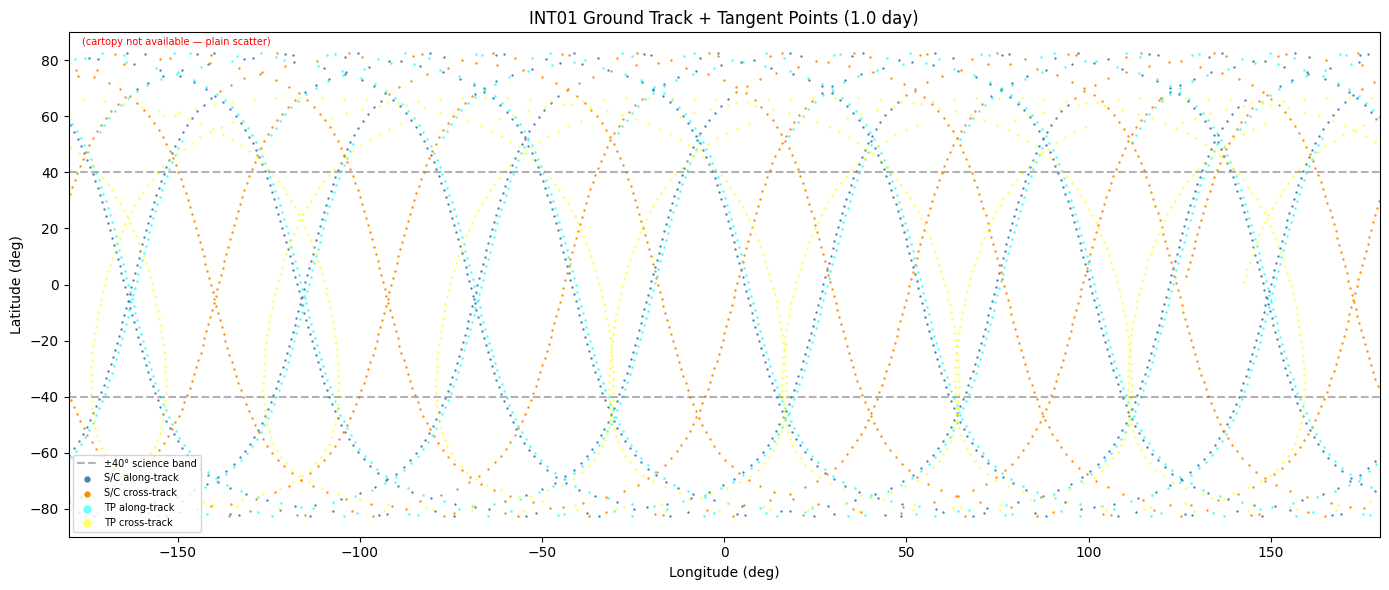

Plot 3.1 saved: outputs/INT01_groundtrack.png


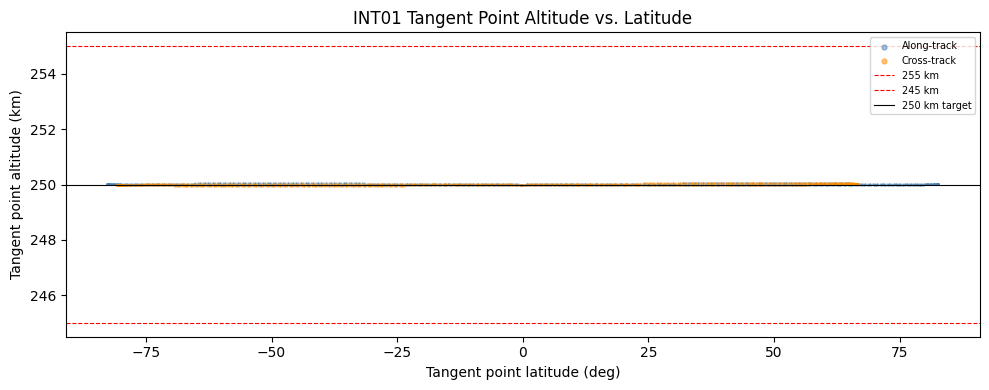

Plot 3.2 saved: outputs/INT01_tp_altitude.png


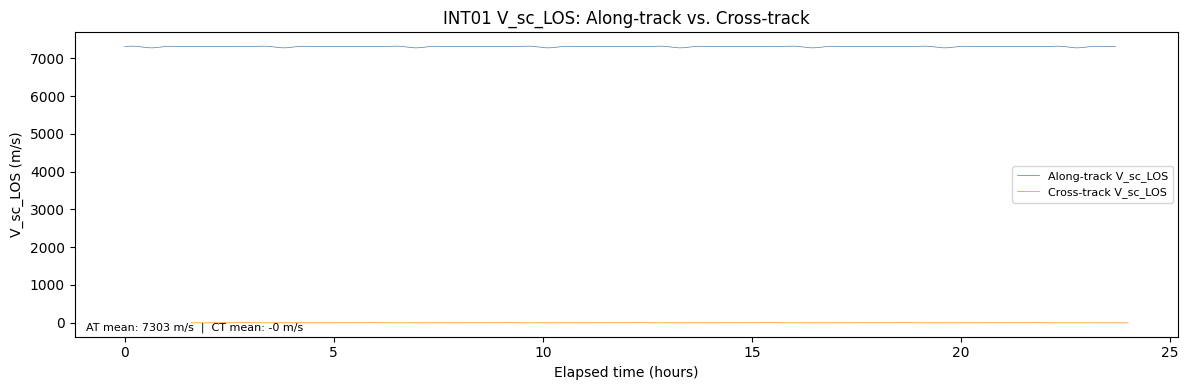

Plot 3.3 saved: outputs/INT01_Vsc_LOS.png


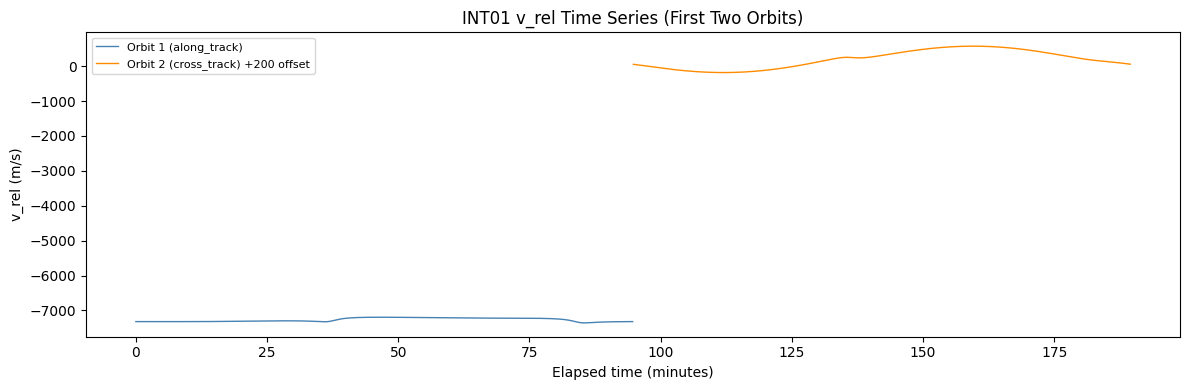

Plot 3.4 saved: outputs/INT01_v_rel_timeseries.png

Visual inspection required:
  3.1: AT tangent points ahead ~8–10° in longitude; CT perpendicular
  3.2: All points within ±5 km of 250 km
  3.3: AT V_sc_LOS ~-7100 m/s >> CT V_sc_LOS (10× ratio visible)
  3.4: v_rel is smooth — no jumps

Section 3: Plots saved


In [3]:
# ── Section 3: Four geometric verification plots ────────────────────────────
import pathlib
pathlib.Path('outputs').mkdir(exist_ok=True)

subsample = max(1, int(len(df_results) / 2000))

# ── Plot 3.1: Ground track and tangent points map ──────────────────────────
if HAS_CARTOPY:
    fig, ax = plt.subplots(figsize=(14, 6),
                            subplot_kw={'projection': ccrs.PlateCarree()})
    ax.add_feature(cf.COASTLINE, linewidth=0.4)
    ax.add_feature(cf.BORDERS,   linewidth=0.2)
    ax.axhline(40,  ls='--', color='gray', alpha=0.6, label='±40° science band')
    ax.axhline(-40, ls='--', color='gray', alpha=0.6)
    transform = ccrs.PlateCarree()
    ax.scatter(df_at.sc_lon[::subsample], df_at.sc_lat[::subsample],
               s=0.5, c='steelblue', label='S/C along-track', transform=transform)
    ax.scatter(df_ct.sc_lon[::subsample], df_ct.sc_lat[::subsample],
               s=0.5, c='darkorange', label='S/C cross-track', transform=transform)
    ax.scatter(df_at.tp_lon[::subsample], df_at.tp_lat[::subsample],
               s=1.0, c='cyan',   alpha=0.5, label='TP along-track', transform=transform)
    ax.scatter(df_ct.tp_lon[::subsample], df_ct.tp_lat[::subsample],
               s=1.0, c='yellow', alpha=0.5, label='TP cross-track', transform=transform)
else:
    fig, ax = plt.subplots(figsize=(14, 6))
    ax.axhline(40,  ls='--', color='gray', alpha=0.6, label='±40° science band')
    ax.axhline(-40, ls='--', color='gray', alpha=0.6)
    ax.scatter(df_at.sc_lon[::subsample], df_at.sc_lat[::subsample],
               s=0.5, c='steelblue', label='S/C along-track')
    ax.scatter(df_ct.sc_lon[::subsample], df_ct.sc_lat[::subsample],
               s=0.5, c='darkorange', label='S/C cross-track')
    ax.scatter(df_at.tp_lon[::subsample], df_at.tp_lat[::subsample],
               s=1.0, c='cyan',   alpha=0.5, label='TP along-track')
    ax.scatter(df_ct.tp_lon[::subsample], df_ct.tp_lat[::subsample],
               s=1.0, c='yellow', alpha=0.5, label='TP cross-track')
    ax.set_xlabel('Longitude (deg)')
    ax.set_ylabel('Latitude (deg)')
    ax.set_xlim(-180, 180)
    ax.set_ylim(-90, 90)
    ax.text(0.01, 0.99, '(cartopy not available — plain scatter)', transform=ax.transAxes,
            va='top', fontsize=7, color='red')

ax.set_title(f"INT01 Ground Track + Tangent Points ({DURATION_DAYS:.1f} day)")
ax.legend(loc='lower left', markerscale=5, fontsize=7)
plt.tight_layout()
plt.savefig('outputs/INT01_groundtrack.png', dpi=150)
plt.show()
print("Plot 3.1 saved: outputs/INT01_groundtrack.png")

# ── Visual check: along-track TPs should lead S/C by ~8–10° longitude; ──────
# cross-track TPs should be ~8–10° perpendicular. Science band (±40°) visible.

# ── Plot 3.2: Tangent point altitude vs. latitude ──────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
ax.scatter(df_at.tp_lat[::subsample], df_at.tp_alt_km[::subsample],
           s=0.5, c='steelblue', alpha=0.5, label='Along-track')
ax.scatter(df_ct.tp_lat[::subsample], df_ct.tp_alt_km[::subsample],
           s=0.5, c='darkorange', alpha=0.5, label='Cross-track')
ax.axhline(H_TARGET_KM + 5, ls='--', color='red',  lw=0.8, label=f'{H_TARGET_KM+5:.0f} km')
ax.axhline(H_TARGET_KM - 5, ls='--', color='red',  lw=0.8, label=f'{H_TARGET_KM-5:.0f} km')
ax.axhline(H_TARGET_KM,     ls='-',  color='black', lw=0.8, label=f'{H_TARGET_KM:.0f} km target')
ax.set_xlabel('Tangent point latitude (deg)')
ax.set_ylabel('Tangent point altitude (km)')
ax.set_title('INT01 Tangent Point Altitude vs. Latitude')
ax.legend(fontsize=7, markerscale=5)
plt.tight_layout()
plt.savefig('outputs/INT01_tp_altitude.png', dpi=150)
plt.show()
print("Plot 3.2 saved: outputs/INT01_tp_altitude.png")

# ── Plot 3.3: V_sc_LOS comparison, both look modes ─────────────────────────
fig, ax = plt.subplots(figsize=(12, 4))
t_at = (df_at['epoch'] - pd.Timestamp(START_EPOCH, tz='UTC')).dt.total_seconds().to_numpy() / 3600
t_ct = (df_ct['epoch'] - pd.Timestamp(START_EPOCH, tz='UTC')).dt.total_seconds().to_numpy() / 3600
ax.plot(t_at[::subsample], df_at.V_sc_LOS.values[::subsample],
        'steelblue', lw=0.5, label='Along-track V_sc_LOS')
ax.plot(t_ct[::subsample], df_ct.V_sc_LOS.values[::subsample],
        'darkorange', lw=0.5, label='Cross-track V_sc_LOS')
ax.set_xlabel('Elapsed time (hours)')
ax.set_ylabel('V_sc_LOS (m/s)')
ax.set_title('INT01 V_sc_LOS: Along-track vs. Cross-track')
ax.legend(fontsize=8)
at_mean = df_at.V_sc_LOS.mean()
ct_mean = df_ct.V_sc_LOS.mean()
ax.text(0.01, 0.02, f'AT mean: {at_mean:.0f} m/s  |  CT mean: {ct_mean:.0f} m/s',
        transform=ax.transAxes, fontsize=8)
plt.tight_layout()
plt.savefig('outputs/INT01_Vsc_LOS.png', dpi=150)
plt.show()
print("Plot 3.3 saved: outputs/INT01_Vsc_LOS.png")

# ── Plot 3.4: v_rel time series, first two orbits ──────────────────────────
orb1 = df_results[df_results.orbit_number == 1].sort_values('epoch')
orb2 = df_results[df_results.orbit_number == 2].sort_values('epoch')

t1 = (orb1['epoch'] - pd.Timestamp(START_EPOCH, tz='UTC')).dt.total_seconds().to_numpy() / 60
t2 = (orb2['epoch'] - pd.Timestamp(START_EPOCH, tz='UTC')).dt.total_seconds().to_numpy() / 60

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(t1, orb1.v_rel.values,
        'steelblue', lw=1.0, label=f'Orbit 1 ({orb1.look_mode.iloc[0]})')
ax.plot(t2, orb2.v_rel.values + 200,
        'darkorange', lw=1.0, label=f'Orbit 2 ({orb2.look_mode.iloc[0]}) +200 offset')
ax.set_xlabel('Elapsed time (minutes)')
ax.set_ylabel('v_rel (m/s)')
ax.set_title('INT01 v_rel Time Series (First Two Orbits)')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('outputs/INT01_v_rel_timeseries.png', dpi=150)
plt.show()
print("Plot 3.4 saved: outputs/INT01_v_rel_timeseries.png")

# Visual confirmation prompt
print("\nVisual inspection required:")
print("  3.1: AT tangent points ahead ~8–10° in longitude; CT perpendicular")
print("  3.2: All points within ±5 km of 250 km")
print("  3.3: AT V_sc_LOS ~-7100 m/s >> CT V_sc_LOS (10× ratio visible)")
print("  3.4: v_rel is smooth — no jumps")
print("\nSection 3: Plots saved")

In [4]:
# ── Section 4: Quantitative verification checks V1–V5 ──────────────────────
print("=" * 60)
print("INT01 Verification Checks V1–V5")
print("=" * 60)

# V1 — Tangent altitude within ±5 km of H_TARGET_KM
alt_dev = (df_results.tp_alt_km - H_TARGET_KM).abs()
v1 = alt_dev.max() < 5.0
print(f"\nV1 — Tangent altitude (target {H_TARGET_KM} km):")
print(f"     Max deviation: {alt_dev.max():.2f} km  (must be < 5 km)")
print(f"     {'PASS' if v1 else 'FAIL'}")

# V2 — TP offset from spacecraft (3-D, projected on velocity / orbit-normal)
# Orbit inclination ~83°: along-track at equator is mostly northward,
# so longitude diff fails for polar orbits; project on velocity/orbit-normal.
eq_at = df_at[df_at.sc_lat.abs() < 5]
eq_ct = df_ct[df_ct.sc_lat.abs() < 5]
v2_at = v2_ct = False

if len(eq_at) > 0:
    _pos = np.column_stack([eq_at.pos_eci_x, eq_at.pos_eci_y, eq_at.pos_eci_z])
    _vel = np.column_stack([eq_at.vel_eci_x, eq_at.vel_eci_y, eq_at.vel_eci_z])
    _tp  = np.column_stack([eq_at.tp_eci_x,  eq_at.tp_eci_y,  eq_at.tp_eci_z])
    _v_hat = _vel / np.linalg.norm(_vel, axis=1, keepdims=True)
    fwd_km = ((_tp - _pos) * _v_hat).sum(axis=1) / 1e3
    mean_fwd_km = fwd_km.mean()
    v2_at = mean_fwd_km > 500
    print()
    print(f'V2a — Along-track TP forward offset at equator (3-D, projected on velocity):')
    print(f'      Mean: {mean_fwd_km:+.0f} km  (expected > 500 km forward)')
    print(f'      {"PASS" if v2_at else "FAIL"}')
else:
    print('V2a — No along-track equatorial epochs found (check orbit coverage)')

if len(eq_ct) > 0:
    _pos = np.column_stack([eq_ct.pos_eci_x, eq_ct.pos_eci_y, eq_ct.pos_eci_z])
    _vel = np.column_stack([eq_ct.vel_eci_x, eq_ct.vel_eci_y, eq_ct.vel_eci_z])
    _tp  = np.column_stack([eq_ct.tp_eci_x,  eq_ct.tp_eci_y,  eq_ct.tp_eci_z])
    _orb_n = np.cross(_pos, _vel)
    _orb_n = _orb_n / np.linalg.norm(_orb_n, axis=1, keepdims=True)
    lat_km = np.abs(((_tp - _pos) * _orb_n).sum(axis=1)) / 1e3
    mean_lat_km = lat_km.mean()
    v2_ct = mean_lat_km > 500
    print()
    print(f'V2b — Cross-track TP lateral offset at equator (3-D, projected on orbit-normal):')
    print(f'      Mean: {mean_lat_km:+.0f} km  (expected > 500 km lateral)')
    print(f'      {"PASS" if v2_ct else "FAIL"}')
else:
    print('V2b — No cross-track equatorial epochs found (check orbit coverage)')

v2 = v2_at and v2_ct

# V3 — V_sc_LOS ratio along-track / cross-track > 10
ratio = abs(df_at.V_sc_LOS.mean()) / (abs(df_ct.V_sc_LOS.mean()) + 1e-6)
v3 = ratio > 10.0
print(f"\nV3 — V_sc_LOS ratio (along-track / cross-track):")
print(f"     Along-track mean: {df_at.V_sc_LOS.mean():.0f} m/s")
print(f"     Cross-track mean: {df_ct.V_sc_LOS.mean():.0f} m/s")
print(f"     Ratio: {ratio:.1f}×  (must be > 10×)")
print(f"     {'PASS' if v3 else 'FAIL'}")

# V4 — No NaN or Inf
num_cols = df_results.select_dtypes(include=np.number)
v4 = (df_results.isna().sum().sum() == 0 and
      np.all(np.isfinite(num_cols.values)))
print(f"\nV4 — No NaN or Inf values in any output column:")
print(f"     NaN count: {df_results.isna().sum().sum()}")
print(f"     {'PASS' if v4 else 'FAIL'}")

# V5 — v_rel smoothness per orbit (no spikes > 100 m/s)
v5_all = True
for orb_num, orb_df in df_results.groupby('orbit_number'):
    diffs = np.abs(np.diff(orb_df.v_rel.values))
    max_jump = diffs.max() if len(diffs) > 0 else 0.0
    ok = max_jump < 100.0
    if not ok:
        print(f"\nV5 — FAIL in orbit {orb_num}: max jump {max_jump:.2f} m/s")
    v5_all = v5_all and ok
print(f"\nV5 — v_rel smoothness (all {n_orbits} orbits, limit 100 m/s):")
print(f"     {'PASS' if v5_all else 'FAIL'}")
v5 = v5_all

all_v1_v5 = all([v1, v2, v3, v4, v5])
print(f"\n── V1–V5 overall: {'PASS' if all_v1_v5 else 'FAIL'} ──")

print("\nSection 4: PASS" if all_v1_v5 else "\nSection 4: FAIL")

INT01 Verification Checks V1–V5

V1 — Tangent altitude (target 250.0 km):
     Max deviation: 0.05 km  (must be < 5 km)
     PASS

V2a — Along-track TP forward offset at equator (3-D, projected on velocity):
      Mean: +1798 km  (expected > 500 km forward)
      PASS

V2b — Cross-track TP lateral offset at equator (3-D, projected on orbit-normal):
      Mean: +1814 km  (expected > 500 km lateral)
      PASS

V3 — V_sc_LOS ratio (along-track / cross-track):
     Along-track mean: 7303 m/s
     Cross-track mean: -0 m/s
     Ratio: 117864.5×  (must be > 10×)
     PASS

V4 — No NaN or Inf values in any output column:
     NaN count: 0
     PASS

V5 — v_rel smoothness (all 16 orbits, limit 100 m/s):
     PASS

── V1–V5 overall: PASS ──

Section 4: PASS


In [5]:
# ── Section 5: Synthetic metadata array generation (V8) ────────────────────
# Build one ImageMetadata per science epoch using P01 build_synthetic_metadata.
# df_results row is used directly as nb01_row since it carries all required
# NB01 fields (pos_eci_x/y/z, vel_eci_x/y/z, sc_lat, sc_lon, sc_alt_km, epoch).

metadata_list = []

for i, row in df_results.iterrows():
    nb02_tp = {
        'tp_lat_deg': row.tp_lat,
        'tp_lon_deg': row.tp_lon,
        'tp_alt_km':  row.tp_alt_km,
        'tp_eci':     [row.tp_eci_x, row.tp_eci_y, row.tp_eci_z],
    }
    nb02_vr = {
        'v_rel':       row.v_rel,
        'v_wind_LOS':  row.v_wind_LOS,
        'V_sc_LOS':    row.V_sc_LOS,
        'v_earth_LOS': row.v_earth_LOS,
        'v_zonal_ms':  row.v_zonal_ms,
        'v_merid_ms':  row.v_merid_ms,
    }
    quaternion_xyzw = [row.q_x, row.q_y, row.q_z, row.q_w]
    los_eci         = np.array([row.los_x, row.los_y, row.los_z])

    meta = build_synthetic_metadata(
        params          = params,
        nb01_row        = row,     # df_results row has sc_lat/sc_lon/sc_alt_km
        nb02_tp         = nb02_tp,
        nb02_vr         = nb02_vr,
        quaternion_xyzw = quaternion_xyzw,
        los_eci         = los_eci,
        look_mode       = row.look_mode,
        img_type        = 'science',
        orbit_number    = int(row.orbit_number),
        frame_sequence  = int(row.frame_sequence),
        noise_seed      = int(i),
    )
    metadata_list.append(meta)

print(f"Generated {len(metadata_list)} ImageMetadata records.")

# Build summary DataFrame
df_metadata = pd.DataFrame([{
    'orbit_number':   m.orbit_number,
    'frame_sequence': m.frame_sequence,
    'epoch':          m.utc_timestamp,
    'img_type':       m.img_type,
    'is_synthetic':   m.is_synthetic,
    'look_mode':      m.obs_mode,
    'orbit_parity':   m.orbit_parity,
    'tp_lat':         m.tangent_lat,
    'tp_lon':         m.tangent_lon,
    'tp_alt_km':      m.tangent_alt_km,
    'truth_v_los':    m.truth_v_los,
    'truth_v_zonal':  m.truth_v_zonal,
    'truth_v_merid':  m.truth_v_meridional,
    'etalon_gap_mm':  m.etalon_gap_mm,
    'adcs_flag':      m.adcs_quality_flag,
} for m in metadata_list])

print(df_metadata[['orbit_number', 'look_mode', 'tp_lat', 'truth_v_los', 'etalon_gap_mm']].describe())

# ── V8 checks ───────────────────────────────────────────────────────────────
print("\nV8 — Synthetic metadata array validation:")

# V8a — All records synthetic with GOOD ADCS flag
v8a = (df_metadata.is_synthetic.all() and
       (df_metadata.adcs_flag == 0).all())
print(f"\nV8a — All is_synthetic=True and adcs_flag=GOOD:")
print(f"     is_synthetic all True: {df_metadata.is_synthetic.all()}")
print(f"     adcs_flag all 0 (GOOD): {(df_metadata.adcs_flag == 0).all()}")
print(f"     {'PASS' if v8a else 'FAIL'}")

# V8b — truth_v_los matches v_wind_LOS from NB02c
truth_diff = (df_metadata.truth_v_los - df_results.v_wind_LOS).abs()
v8b = truth_diff.max() < 1e-6
print(f"\nV8b — truth_v_los matches v_wind_LOS from NB02c:")
print(f"     Max diff: {truth_diff.max():.2e} m/s  (must be < 1e-6 m/s)")
print(f"     {'PASS' if v8b else 'FAIL'}")

# V8c — tangent point fields match df_results
tp_lat_diff = (df_metadata.tp_lat - df_results.tp_lat).abs()
v8c = tp_lat_diff.max() < 1e-8
print(f"\nV8c — tangent_lat matches tp_lat from NB02b:")
print(f"     Max diff: {tp_lat_diff.max():.2e} deg  (must be < 1e-8 deg)")
print(f"     {'PASS' if v8c else 'FAIL'}")

# V8d — orbit_parity consistent with orbit_number
parity_ok = df_metadata.apply(
    lambda r: (r.orbit_parity == 'along_track') == (r.orbit_number % 2 == 1),
    axis=1,
)
v8d = parity_ok.all()
print(f"\nV8d — orbit_parity consistent with orbit_number parity:")
print(f"     All consistent: {parity_ok.all()}")
print(f"     {'PASS' if v8d else 'FAIL'}")

# V8e — No None/NaN in required synthetic fields
required_cols = [
    'tp_lat', 'tp_lon', 'tp_alt_km', 'truth_v_los',
    'truth_v_zonal', 'truth_v_merid', 'etalon_gap_mm',
]
has_none = df_metadata[required_cols].isna().sum()
v8e = has_none.sum() == 0
print(f"\nV8e — No None/NaN in required synthetic fields:")
if not v8e:
    print(f"     Columns with None: {has_none[has_none > 0].to_dict()}")
print(f"     {'PASS' if v8e else 'FAIL'}")

v8 = all([v8a, v8b, v8c, v8d, v8e])
print(f"\n── V8 overall: {'PASS' if v8 else 'FAIL'} ──")

print("\nSection 5: PASS" if v8 else "\nSection 5: FAIL")

Generated 8641 ImageMetadata records.
       orbit_number       tp_lat  truth_v_los  etalon_gap_mm
count   8641.000000  8641.000000  8641.000000   8.641000e+03
mean       8.098137    -1.254909   -16.930183   2.000800e+01
std        4.383534    48.895804    73.832619   3.552919e-15
min        1.000000   -82.712737  -111.803378   2.000800e+01
25%        4.000000   -44.466713   -82.014509   2.000800e+01
50%        8.000000    -0.010705   -43.465780   2.000800e+01
75%       12.000000    42.325261    36.545753   2.000800e+01
max       16.000000    82.713018   111.803323   2.000800e+01

V8 — Synthetic metadata array validation:

V8a — All is_synthetic=True and adcs_flag=GOOD:
     is_synthetic all True: True
     adcs_flag all 0 (GOOD): True
     PASS

V8b — truth_v_los matches v_wind_LOS from NB02c:
     Max diff: 0.00e+00 m/s  (must be < 1e-6 m/s)
     PASS

V8c — tangent_lat matches tp_lat from NB02b:
     Max diff: 0.00e+00 deg  (must be < 1e-8 deg)
     PASS

V8d — orbit_parity consiste


V8e — No None/NaN in required synthetic fields:
     PASS

── V8 overall: PASS ──

Section 5: PASS


In [6]:
# ── Section 6: L2 Round-trip Wind Decomposition (V6 and V7) ────────────────
#
# For each 5°-longitude bin with tangent points from both look modes,
# solve the 2×2 system:  G · [v_zonal, v_merid]^T = d
# where G[i,:] = [los · e_east, los · e_north]  and  d[i] = v_wind_LOS
#
# los_dot_east and los_dot_north were stored in df_results during Section 2.

def _run_l2_recovery(df_sub, v_wind_los_col='v_wind_LOS', science_band_deg=40):
    """
    Longitude-bin L2 recovery. Returns DataFrame with v_zonal_rec, v_merid_rec.
    Uses stored los_dot_east / los_dot_north columns in df_sub.
    """
    recovered = []
    for lon_bin in np.arange(-180, 180, 5.0):
        at_mask = ((df_sub.tp_lon >= lon_bin) & (df_sub.tp_lon < lon_bin + 5) &
                   (df_sub.tp_lat.abs() < science_band_deg) &
                   (df_sub.look_mode == 'along_track'))
        ct_mask = ((df_sub.tp_lon >= lon_bin) & (df_sub.tp_lon < lon_bin + 5) &
                   (df_sub.tp_lat.abs() < science_band_deg) &
                   (df_sub.look_mode == 'cross_track'))
        if at_mask.sum() < 1 or ct_mask.sum() < 1:
            continue

        at_row = df_sub[at_mask].iloc[0]
        ct_row = df_sub[ct_mask].iloc[0]

        G = np.array([
            [at_row.los_dot_east, at_row.los_dot_north],
            [ct_row.los_dot_east, ct_row.los_dot_north],
        ])
        d = np.array([at_row[v_wind_los_col], ct_row[v_wind_los_col]])
        result, *_ = np.linalg.lstsq(G, d, rcond=None)
        recovered.append({'lon_bin': lon_bin, 'v_zonal_rec': result[0],
                          'v_merid_rec': result[1]})
    return pd.DataFrame(recovered)


# ── V6: Primary wind map (100, 50) m/s ─────────────────────────────────────
df_rec = _run_l2_recovery(df_results, v_wind_los_col='v_wind_LOS')
bias_z = (df_rec.v_zonal_rec - 100.0).mean()
bias_m = (df_rec.v_merid_rec -  50.0).mean()
rms_z  = (df_rec.v_zonal_rec - 100.0).std()
rms_m  = (df_rec.v_merid_rec -  50.0).std()
v6 = (abs(bias_z) < 1.0 and abs(bias_m) < 1.0 and rms_z < 2.0 and rms_m < 2.0)
print(f"V6 — L2 round-trip (primary wind 100, 50 m/s) [{len(df_rec)} lon bins]:")
print(f"     Zonal:  bias={bias_z:+.3f}, RMS={rms_z:.3f} m/s")
print(f"     Merid:  bias={bias_m:+.3f}, RMS={rms_m:.3f} m/s")
print(f"     {'PASS' if v6 else 'FAIL'}")

# ── V7: Secondary wind maps ─────────────────────────────────────────────────
# Use stored los_dot_east / los_dot_north to compute v_wind_LOS for each
# secondary map without re-running the full geometry loop.

secondary_maps = [
    ('zonal_only',  200.0, 0.0),
    ('merid_only',    0.0, 150.0),
    ('zero_wind',     0.0,   0.0),
]

v7_all = True
for label, vz, vm in secondary_maps:
    # v_wind_LOS = v_zonal * (los · e_east) + v_merid * (los · e_north)
    df_results[f'v_wind_LOS_{label}'] = (
        vz * df_results['los_dot_east'] + vm * df_results['los_dot_north']
    )
    df_sec = _run_l2_recovery(df_results, v_wind_los_col=f'v_wind_LOS_{label}')
    bz = (df_sec.v_zonal_rec - vz).mean()
    bm = (df_sec.v_merid_rec - vm).mean()
    rz = (df_sec.v_zonal_rec - vz).std()
    rm = (df_sec.v_merid_rec - vm).std()
    ok = (abs(bz) < 1.0 and abs(bm) < 1.0 and rz < 2.0 and rm < 2.0)
    v7_all = v7_all and ok
    print(f"V7 — {label} ({vz:.0f}, {vm:.0f}) [{len(df_sec)} bins]:")
    print(f"     Zonal:  bias={bz:+.3f}, RMS={rz:.3f} m/s")
    print(f"     Merid:  bias={bm:+.3f}, RMS={rm:.3f} m/s")
    print(f"     {'PASS' if ok else 'FAIL'}")

v7 = v7_all

all_checks = all([v1, v2, v3, v4, v5, v6, v7, v8])
print(f"\n── V6–V7 overall: {'PASS' if (v6 and v7) else 'FAIL'} ──")
print(f"── ALL CHECKS V1–V8: {'PASS' if all_checks else 'FAIL'} ──")

print("\nSection 6: PASS" if (v6 and v7) else "\nSection 6: FAIL")

V6 — L2 round-trip (primary wind 100, 50 m/s) [49 lon bins]:
     Zonal:  bias=-0.000, RMS=0.000 m/s
     Merid:  bias=-0.000, RMS=0.000 m/s
     PASS
V7 — zonal_only (200, 0) [49 bins]:
     Zonal:  bias=-0.000, RMS=0.000 m/s
     Merid:  bias=-0.000, RMS=0.000 m/s
     PASS


V7 — merid_only (0, 150) [49 bins]:
     Zonal:  bias=-0.000, RMS=0.000 m/s
     Merid:  bias=-0.000, RMS=0.000 m/s
     PASS


V7 — zero_wind (0, 0) [49 bins]:
     Zonal:  bias=+0.000, RMS=0.000 m/s
     Merid:  bias=+0.000, RMS=0.000 m/s
     PASS

── V6–V7 overall: PASS ──
── ALL CHECKS V1–V8: PASS ──

Section 6: PASS


In [7]:
# ── Section 7: Save results and progress checkpoint ─────────────────────────
import json

pathlib.Path('outputs').mkdir(exist_ok=True)

# Drop secondary v_wind_LOS columns before saving (keep results clean)
cols_to_drop = [c for c in df_results.columns if c.startswith('v_wind_LOS_')]
df_save = df_results.drop(columns=cols_to_drop)
df_save.to_csv('outputs/INT01_results.csv', index=False)
print(f"Saved {len(df_save)} rows to outputs/INT01_results.csv")

df_metadata.to_csv('outputs/INT01_metadata_summary.csv', index=False)
print(f"Saved metadata summary ({len(df_metadata)} rows) to outputs/INT01_metadata_summary.csv")

# Write metadata sidecar JSON for first and last science epochs
write_sidecar(metadata_list[0],  pathlib.Path('outputs/INT01_metadata_first.json'))
write_sidecar(metadata_list[-1], pathlib.Path('outputs/INT01_metadata_last.json'))
print("Saved sidecar JSON: outputs/INT01_metadata_first.json")
print("Saved sidecar JSON: outputs/INT01_metadata_last.json")

# Progress checkpoint
cp_path = pathlib.Path('simulations/checkpoints/progress.json')
cp_path.parent.mkdir(parents=True, exist_ok=True)
cp = json.loads(cp_path.read_text()) if cp_path.exists() else {}

checks_passed = sum([v1, v2, v3, v4, v5, v6, v7, v8])
cp['INT01_geometry_pipeline'] = {
    'status':        'complete',
    'checks_passed': int(checks_passed),
    'duration_days': DURATION_DAYS,
    'n_orbits':      int(n_orbits),
    'n_epochs':      len(df_results),
    'n_metadata':    len(metadata_list),
    'V6_bias_zonal': float(bias_z),
    'V6_bias_merid': float(bias_m),
    'notes': (
        f"V1–V8 {'all PASS' if checks_passed == 8 else f'{checks_passed}/8 PASS'}. "
        f"Bias zonal={bias_z:.3f} m/s, merid={bias_m:.3f} m/s. "
        f"Duration {DURATION_DAYS:.1f} day, {n_orbits} orbits, "
        f"{len(metadata_list)} synthetic ImageMetadata records."
    ),
}
cp_path.write_text(json.dumps(cp, indent=2))
print(f"Progress checkpoint updated ({checks_passed}/8 checks passed).")

# Final summary
print("\n" + "=" * 60)
print("INT01 IMPLEMENTATION REPORT")
print("=" * 60)
print(f"Spec version: INT01_geometry_notebook_2026-04-16.md")
checks = {'V1': v1, 'V2': v2, 'V3': v3, 'V4': v4,
          'V5': v5, 'V6': v6, 'V7': v7, 'V8': v8}
passing = [k for k, v in checks.items() if v]
failing = [k for k, v in checks.items() if not v]
print(f"Checks passed: {', '.join(passing)}")
if failing:
    print(f"Checks FAILED: {', '.join(failing)}")
print(f"Duration: {DURATION_DAYS:.1f} day(s), {n_orbits} orbits, {len(df_results)} epochs")
print(f"V6 bias:  zonal={bias_z:+.3f} m/s, merid={bias_m:+.3f} m/s")
print(f"V8 metadata records: {len(metadata_list)}")
print(f"NB02 boresight confirmed: -X_BRF (np.array([-1., 0., 0.]))")
print(f"InstrumentParams: {'M01' if type(params).__name__ == 'InstrumentParams' else 'stub'}")
print(f"Overall: {'ALL PASS' if checks_passed == 8 else f'{checks_passed}/8 PASS'}")

print("\nSection 7: PASS")

Saved 8641 rows to outputs/INT01_results.csv
Saved metadata summary (8641 rows) to outputs/INT01_metadata_summary.csv
Saved sidecar JSON: outputs/INT01_metadata_first.json
Saved sidecar JSON: outputs/INT01_metadata_last.json
Progress checkpoint updated (8/8 checks passed).

INT01 IMPLEMENTATION REPORT
Spec version: INT01_geometry_notebook_2026-04-16.md
Checks passed: V1, V2, V3, V4, V5, V6, V7, V8
Duration: 1.0 day(s), 16 orbits, 8641 epochs
V6 bias:  zonal=-0.000 m/s, merid=-0.000 m/s
V8 metadata records: 8641
NB02 boresight confirmed: -X_BRF (np.array([-1., 0., 0.]))
InstrumentParams: M01
Overall: ALL PASS

Section 7: PASS
